# c-GC* Motor-Neuron Analysis

This notebook runs the supplied `GcStar` c-GC implementation on the Zenodo motor-neuron dataframe in `data/motoneurons`.
It analyzes every unique `Fish`/`Trace`/`fluo_type` trace by default, saves weighted retained adjacency matrices to a `.pkl`, and reloads the cache for plotting so visualization does not require rerunning the estimator.

The saved `adjacency` and `weighted_adjacency` matrices are weighted retained scores in `[source, target]` orientation. Zero means no retained edge; the boolean support is saved separately as `mask`.


<!-- reviewer-resume-contract -->
## Execution and resume contract

This notebook is aligned with the reviewer-revision implementation. Expensive work is checkpointed and safe to restart with the same configuration. Do not change methods, seeds, thresholds, or output paths while resuming. Saved outputs remain provisional until the compute-machine run and verification gates complete.


In [1]:
from pathlib import Path
from datetime import datetime
import hashlib
import importlib.util
import os
import pickle
import sys
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        "The Zenodo dataframe files are pandas pickles. Install pandas in this "
        "notebook kernel before running this analysis."
    ) from exc

CAUSALISED_GC_RELATIVE_PATH = Path("src/core/causalised-GC.py")
PACKAGE_RELATIVE_PATH = Path("src/calcium_transient_rising_flank")


def find_project_root() -> Path:
    search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for base in search_roots:
        for candidate in (base, base / "calcium-transient-rising-flank"):
            if (
                (candidate / PACKAGE_RELATIVE_PATH).exists()
                and (candidate / CAUSALISED_GC_RELATIVE_PATH).exists()
            ):
                return candidate
    raise FileNotFoundError(
        "Could not find the calcium-transient-rising-flank repository; "
        "run from the repository, notebooks directory, or outer rising_flanks workspace."
    )


PROJECT_ROOT = find_project_root()

SRC = PROJECT_ROOT / "src"
CORE = SRC / "core"
for path in (SRC, CORE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

CAUSALISED_GC_PATH = PROJECT_ROOT / CAUSALISED_GC_RELATIVE_PATH
spec = importlib.util.spec_from_file_location("causalised_gc", CAUSALISED_GC_PATH)
causalised_gc = importlib.util.module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = causalised_gc
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded GcStar from {CAUSALISED_GC_PATH}")

from calcium_transient_rising_flank import graph_summary, plot_directed_graph, plot_matrix, write_summary_csv
from calcium_transient_rising_flank import array_input_digest
from calcium_transient_rising_flank.checkpointing import atomic_write_pickle, load_pickle as load_checkpoint_pickle


Project root: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank
Loaded GcStar from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/src/core/causalised-GC.py


## Configure Data, Estimator, and Outputs


In [2]:
METHOD = "cgc-star"
METHOD_SLUG = "cgc_star"
NOTEBOOK_NAME = "c-GC-star_Motoneurons.ipynb"

DATA_FILE = PROJECT_ROOT / "data" / "motoneurons" / "df_motorneurons_F3T1_F3T2_F5T2.pkl"
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Expected motoneuron dataframe at {DATA_FILE}")

# Manuscript-level defaults. Override from the shell before launching Jupyter if needed.
ALPHA = float(os.environ.get("RF_ALPHA", "0.01"))
BETA = float(os.environ.get("RF_CONDITIONAL_ALPHA", "0.001"))
N_PASTS = int(os.environ.get("RF_N_PASTS", "5"))
N_LAGS = int(os.environ.get("RF_N_LAGS", "2"))
N_PERM = int(os.environ.get("RF_N_PERMUTATIONS", "1000"))
SIMULATION = os.environ.get("RF_SIMULATION", "1").lower() not in {"0", "false", "no"}
PARALLEL = os.environ.get("RF_PARALLEL", "0").lower() in {"1", "true", "yes"}
VERBOSE = int(os.environ.get("RF_GC_VERBOSE", "0"))

# Empty means use every unique Fish/Trace/fluo_type trace in the dataframe.
FLUO_TYPES = tuple(
    item.strip()
    for item in os.environ.get("RF_FLUO_TYPES", "").split(",")
    if item.strip()
)
MAX_RECORDINGS = int(os.environ.get("RF_MAX_RECORDINGS", "0"))

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "motorneurons"
FIGURE_DIR = PROJECT_ROOT.parent / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ADJACENCY_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_motoneurons_weighted_adjacency_matrices.pkl"
SUMMARY_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_motoneurons_summary_rows.pkl"
SUMMARY_CSV_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_motoneurons_summary_rows.csv"
RESUME = True
IMPLEMENTATION_REVISION = 'reviewer-2026-08-v2'
FIT_CHECKPOINT_DIR = OUTPUT_DIR / 'notebook_checkpoints' / METHOD_SLUG
FIGURE_OUTPUT_FILE = FIGURE_DIR / f"{METHOD_SLUG}_motoneurons_weighted_adjacency.png"

print(f"Using motoneuron data file: {DATA_FILE}")
print(f"Method={METHOD}; alpha={ALPHA}; beta={BETA}; n_perm={N_PERM}; n_pasts={N_PASTS}; n_lags={N_LAGS}")


Using motoneuron data file: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/motoneurons/df_motorneurons_F3T1_F3T2_F5T2.pkl
Method=cgc-star; alpha=0.01; beta=0.001; n_perm=1000; n_pasts=5; n_lags=2


## Load Motor-Neuron Data


In [3]:
def _clean_traces(raw, expected_cells=None):
    values = np.asarray(raw, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"Expected 2-D traces, got shape {values.shape}")
    if expected_cells is not None and values.shape[0] != expected_cells and values.shape[1] == expected_cells:
        values = values.T
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    if values.shape[0] > values.shape[1]:
        raise ValueError(
            f"Trace matrix looks transposed or too short: {values.shape}. Expected [n_cells, n_timepoints]."
        )
    return values


def load_motoneuron_records(path):
    df = pd.read_pickle(path)
    if not hasattr(df, "iterrows"):
        raise TypeError(f"Expected a pandas DataFrame, got {type(df)!r}")

    trace_column = "Trial" if "Trial" in df.columns else "Trace" if "Trace" in df.columns else None
    required = {"Fish", "fluo", "fluo_type", "mid"}
    missing = required.difference(df.columns)
    if trace_column is None:
        missing.add("Trial/Trace")
    if missing:
        raise KeyError(f"Motoneuron dataframe is missing required columns: {sorted(missing)}")

    records = []
    seen = set()
    for _, row in df.iterrows():
        fluo_type = str(row["fluo_type"])
        if FLUO_TYPES and fluo_type not in FLUO_TYPES:
            continue
        key = (int(row["Fish"]), int(row[trace_column]), fluo_type)
        if key in seen:
            continue
        seen.add(key)
        expected_cells = int(row["n_cells"]) if "n_cells" in df.columns else None
        traces = _clean_traces(row["fluo"], expected_cells=expected_cells)
        records.append(
            {
                "key": key,
                "recording": f"F{key[0]}T{key[1]}",
                "fish": key[0],
                "trial": key[1],
                "fluo_type": fluo_type,
                "traces": traces,
                "mid": int(row["mid"]),
                "n_cells": int(traces.shape[0]),
                "n_timepoints": int(traces.shape[1]),
                "input_digest": array_input_digest(traces),
            }
        )
        if MAX_RECORDINGS and len(records) >= MAX_RECORDINGS:
            break
    if not records:
        raise ValueError("No motoneuron records matched the requested filters.")
    return records


records = load_motoneuron_records(DATA_FILE)
for record in records:
    print(
        f"Loaded {record['recording']} {record['fluo_type']}: "
        f"{record['n_cells']} cells x {record['n_timepoints']} frames; mid={record['mid']}"
    )


Loaded F3T1 dff: 14 cells x 1000 frames; mid=7
Loaded F3T2 dff: 11 cells x 1000 frames; mid=6
Loaded F5T2 dff: 17 cells x 1000 frames; mid=9
Loaded F3T1 f_smooth: 14 cells x 1000 frames; mid=7
Loaded F3T2 f_smooth: 11 cells x 1000 frames; mid=6
Loaded F5T2 f_smooth: 17 cells x 1000 frames; mid=9


## Fit and Save Weighted Adjacency Matrices


In [4]:
def _fit_checkpoint_path(traces):
    values = np.ascontiguousarray(np.asarray(traces, dtype=float))
    digest = hashlib.sha256(values.view(np.uint8)).hexdigest()
    config = (IMPLEMENTATION_REVISION, METHOD, ALPHA, BETA, N_PASTS, N_LAGS, N_PERM, SIMULATION)
    suffix = hashlib.sha256(repr(config).encode()).hexdigest()[:16]
    return FIT_CHECKPOINT_DIR / f'{digest}-{suffix}.pkl'


def fit_gcstar(traces):
    checkpoint = _fit_checkpoint_path(traces)
    if RESUME and checkpoint.is_file():
        cached = load_checkpoint_pickle(checkpoint)
        estimator = SimpleNamespace(
            corr_=cached['corr'], pVal_corr_=cached['p_values_corr'],
            inv_corr_=cached['inv_corr'], pVal_inv_corr_=cached['p_values_inv_corr'],
            method=cached['method_internal'],
        )
        return estimator, np.asarray(cached['matrix'], dtype=float)
    estimator = GcStar(
        n_perm=N_PERM,
        n_pasts=N_PASTS,
        n_lags=N_LAGS,
        temporal=True,
        method=METHOD,
        parallel=PARALLEL,
    )
    estimator.fit(traces, verbose=VERBOSE)
    matrix = estimator.get_connectivity_matrix(
        alpha=ALPHA,
        beta=BETA,
        simulation=False,
    )
    matrix = np.nan_to_num(np.asarray(matrix, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(matrix, 0.0)
    atomic_write_pickle(checkpoint, {
        'matrix': matrix, 'corr': np.asarray(estimator.corr_, dtype=float),
        'p_values_corr': np.asarray(estimator.pVal_corr_, dtype=float),
        'inv_corr': np.asarray(estimator.inv_corr_, dtype=float),
        'p_values_inv_corr': np.asarray(estimator.pVal_inv_corr_, dtype=float),
        'method_internal': estimator.method,
    })
    return estimator, matrix


def _estimator_payload(estimator, matrix):
    return {
        "adjacency": matrix,
        "weighted_adjacency": matrix,
        "mask": matrix > 0.0,
        "corr": np.asarray(estimator.corr_, dtype=float),
        "p_values_corr": np.asarray(estimator.pVal_corr_, dtype=float),
        "inv_corr": np.asarray(estimator.inv_corr_, dtype=float),
        "p_values_inv_corr": np.asarray(estimator.pVal_inv_corr_, dtype=float),
        "method_internal": estimator.method,
    }

results = {}
summary_rows = []
for index, record in enumerate(records, start=1):
    print(f"[{index}/{len(records)}] Fitting {METHOD} on {record['recording']} {record['fluo_type']}...", flush=True)
    estimator, matrix = fit_gcstar(record["traces"])
    summary = graph_summary(matrix, record["mid"], binary=False)
    payload = _estimator_payload(estimator, matrix)
    payload.update(
        {
            "recording": record["recording"],
            "fish": record["fish"],
            "trial": record["trial"],
            "fluo_type": record["fluo_type"],
            "mid": record["mid"],
            "n_cells": record["n_cells"],
            "n_timepoints": record["n_timepoints"],
            "input_digest": record["input_digest"],
            "summary": summary,
        }
    )
    results[record["key"]] = payload
    summary_rows.append(
        {
            "dataset": "motoneurons",
            "recording": record["recording"],
            "fish": record["fish"],
            "trial": record["trial"],
            "fluo_type": record["fluo_type"],
            "method": METHOD,
            "method_internal": estimator.method,
            "representation": "full_trace",
            "graph_label": "full_trace",
            "binary": False,
            "input_digest": record["input_digest"],
            **summary,
        }
    )
    print(
        f"    retained_edges={summary['retained_edges']}; "
        f"edge_density={summary['edge_density']:.4f}; "
        f"W_IC={summary['w_ic']}; W_RC={summary['w_rc']}"
    )

adjacency_cache = {
    "metadata": {
        "dataset": "motoneurons",
        "source_file": str(DATA_FILE),
        "notebook": NOTEBOOK_NAME,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "method_requested": METHOD,
        "alpha": ALPHA,
        "beta": BETA,
        "n_pasts": N_PASTS,
        "n_lags": N_LAGS,
        "n_perm": N_PERM,
        "simulation": SIMULATION,
        "adjacency_definition": "weighted retained c-GC score matrix; zero means absent edge",
        "orientation": "[source, target]",
        "summary_metrics": "graph_summary: W_IC, W_RC, edge density, retained edges, and retained weights",
    },
    "records": results,
    "summary_rows": summary_rows,
}

atomic_write_pickle(ADJACENCY_OUTPUT_FILE, adjacency_cache)
atomic_write_pickle(SUMMARY_OUTPUT_FILE, summary_rows)
write_summary_csv(summary_rows, SUMMARY_CSV_OUTPUT_FILE)

print(f"Saved weighted adjacency cache to {ADJACENCY_OUTPUT_FILE}")
print(f"Saved summary rows to {SUMMARY_OUTPUT_FILE}")
print(f"Saved summary CSV to {SUMMARY_CSV_OUTPUT_FILE}")


[1/6] Fitting cgc-star on F3T1 dff...
    retained_edges=57; edge_density=0.3132; W_IC=1.0; W_RC=0.5324433054719168
[2/6] Fitting cgc-star on F3T2 dff...
    retained_edges=38; edge_density=0.3455; W_IC=0.9940859406123008; W_RC=0.5129539831476008
[3/6] Fitting cgc-star on F5T2 dff...
    retained_edges=119; edge_density=0.4375; W_IC=0.899080233274679; W_RC=0.48261070124401956
[4/6] Fitting cgc-star on F3T1 f_smooth...
    retained_edges=48; edge_density=0.2637; W_IC=1.0; W_RC=0.5015623754049983
[5/6] Fitting cgc-star on F3T2 f_smooth...
    retained_edges=28; edge_density=0.2545; W_IC=1.0; W_RC=0.5000698564111289
[6/6] Fitting cgc-star on F5T2 f_smooth...
    retained_edges=88; edge_density=0.3235; W_IC=1.0; W_RC=0.5032807418454845
Saved weighted adjacency cache to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/cgc_star_motoneurons_weighted_adjacency_matrices.pkl
Saved summary rows to /Users/sadiqadedayo/Documents/projects/risin

## Reload Saved Adjacency Cache


In [5]:
def load_adjacency_cache(path=ADJACENCY_OUTPUT_FILE):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


adjacency_cache = load_adjacency_cache()
print(f"Loaded cache from {ADJACENCY_OUTPUT_FILE}")
print(adjacency_cache["metadata"])
print(f"Available records: {list(adjacency_cache['records'].keys())}")


Loaded cache from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/cgc_star_motoneurons_weighted_adjacency_matrices.pkl
{'dataset': 'motoneurons', 'source_file': '/Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/motoneurons/df_motorneurons_F3T1_F3T2_F5T2.pkl', 'notebook': 'c-GC-star_Motoneurons.ipynb', 'created_at': '2026-07-26T16:01:43', 'method_requested': 'cgc-star', 'alpha': 0.01, 'beta': 0.001, 'n_pasts': 5, 'n_lags': 2, 'n_perm': 1000, 'simulation': True, 'adjacency_definition': 'weighted retained c-GC score matrix; zero means absent edge', 'orientation': '[source, target]', 'summary_metrics': 'graph_summary: W_IC, W_RC, edge density, retained edges, and retained weights'}
Available records: [(3, 1, 'dff'), (3, 2, 'dff'), (5, 2, 'dff'), (3, 1, 'f_smooth'), (3, 2, 'f_smooth'), (5, 2, 'f_smooth')]


## Plot Saved Results


Saved figure to /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/cgc_star_motoneurons_weighted_adjacency.png


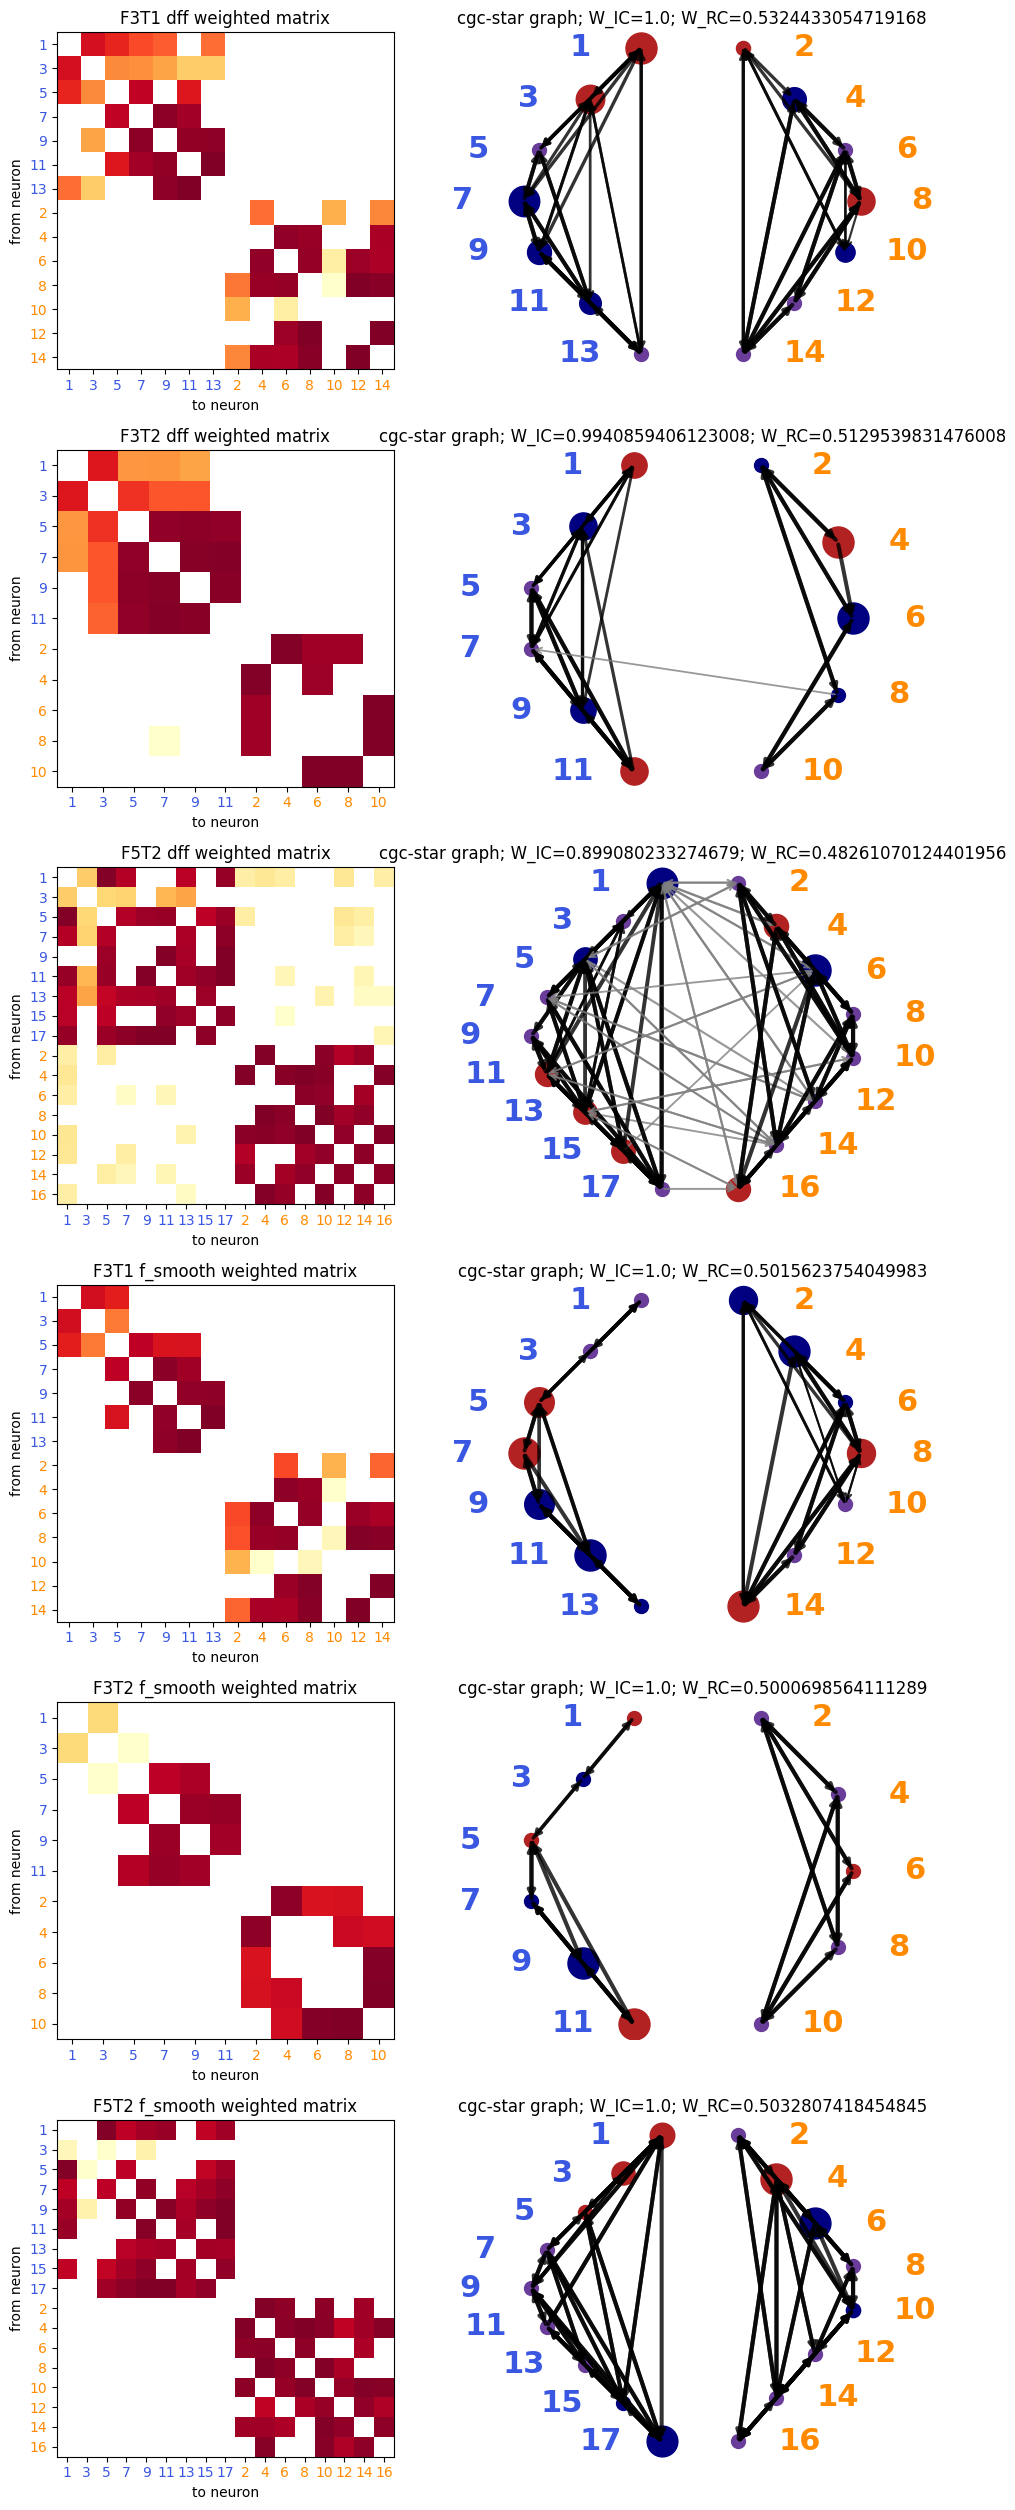

In [6]:
def plot_motoneuron_cache(cache, max_plots=None):
    items = list(cache["records"].items())
    if max_plots is not None:
        items = items[:max_plots]
    if not items:
        raise ValueError("No records available to plot.")
    fig, axes = plt.subplots(len(items), 2, figsize=(10, 4.2 * len(items)))
    axes = np.atleast_2d(axes)
    for row_index, (key, payload) in enumerate(items):
        matrix = np.asarray(payload["weighted_adjacency"], dtype=float)
        mid = int(payload["mid"])
        summary = payload.get("summary", graph_summary(matrix, mid, binary=False))
        plot_matrix(matrix, mid, ax=axes[row_index, 0])
        axes[row_index, 0].set_title(
            f"{payload['recording']} {payload['fluo_type']} weighted matrix"
        )
        plot_directed_graph(matrix, mid, ax=axes[row_index, 1])
        axes[row_index, 1].set_title(
            f"{METHOD} graph; W_IC={summary.get('w_ic')}; W_RC={summary.get('w_rc')}"
        )
    fig.tight_layout()
    return fig


plot_cache = adjacency_cache if "adjacency_cache" in globals() else load_adjacency_cache()
fig = plot_motoneuron_cache(plot_cache, max_plots=None)
fig.savefig(FIGURE_OUTPUT_FILE, dpi=300, bbox_inches="tight")
print(f"Saved figure to {FIGURE_OUTPUT_FILE}")
plt.show()
